In [1]:
import signac
import os
import sys
import pandas as pd
import shutil
import nglview as nv
import MDAnalysis as mda
import numpy as np
import matplotlib.cm as cm
import itertools
import pyarrow.parquet as pq

In [2]:
path_git='../../cascade_computing' #todo - path to git
sys.path.append(path_git)
print(os.path.exists(os.path.join(path_git, 'src')))

True


In [3]:
from src.compute.signac import sgnc as sgnc
from src.compute.utils import toolbox_plots as ptools
from src.compute.utils import toolbox_normalization as ntools
from src.compute.functions import pivot_analysis as etools

In [4]:
p_name='MUT16_FFR_atm_analysis_tiny' 
path=path_git+'/examples' 
project_path= path +'/' + p_name

In [5]:
project= sgnc.MyProject.get_project(project_path)
project

,sp.mols,sp.n_mols,sp.geo_mols,sp.replica_index,sp.structure_index,doc.domains,doc.output_path,doc.top,doc.top_mix,doc.top_org,...,doc.res_org_prob,doc.res_org_freq,doc.res_org_perc,doc.struc_id_prob,doc.struc_id_freq,doc.struc_id_perc,doc.res_dom_prob,doc.res_dom_freq,doc.res_dom_perc,doc.data_path
54544235add59ef9295f39739c202cb5,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,4,0,[],/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...
31fdac587cc5c5717a8739580694a49c,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,10,0,[],/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...
a3a724f3dd192659771f08027a756af8,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,8,0,[],/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...,/Users/lucia/cc/cascade_computing/examples/MUT...


#### connect data (choose dataset)

In [6]:
#connect data for lifetimes
for job in project:
    job.doc.data_path=job.path+'/results_files_lifetimes'
    job.doc.contact_path=job.doc.data_path
    job.doc.results_path=job.doc.data_path

project.run(progress=True,num_passes=1, order="by-job", names=['connecting_data'])#, jobs=[job])

  0%|          | 0/3 [00:00<?, ?it/s]

/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_tiny/workspace/54544235add59ef9295f39739c202cb5/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_54544235add59ef9295f39739c202cb5
gro True pdb True xtc False tcl True traj_meta True
/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_tiny/workspace/31fdac587cc5c5717a8739580694a49c/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_31fdac587cc5c5717a8739580694a49c
gro True pdb True xtc False tcl True traj_meta True
/Users/lucia/cc/cascade_computing/examples/MUT16_FFR_atm_analysis_tiny/workspace/a3a724f3dd192659771f08027a756af8/results_files_lifetimes/MUT16_FFR_atm_analysis_MUT16_65_a3a724f3dd192659771f08027a756af8
gro True pdb True xtc False tcl True traj_meta True


In [7]:
#connect data for frequencies
#for job in project:
#    job.doc.data_path=job.path+'/results_files'
#    job.doc.contact_path=job.doc.data_path
#    job.doc.results_path=job.doc.data_path

#project.run(progress=True,num_passes=1, order="by-job", names=['connecting_data'])#, jobs=[job])

#### choose a single job

In [8]:
job = project.open_job(id='54544235add59ef9295f39739c202cb5')

#### load contact data

In [9]:
#available files

#job.document['gro']
#job.document['pdb']
#job.document['tcl'] 

#job.document['contact_record'] 
#job.document['contact_meta'] 

#job.document['res_type_freq']
#job.document['res_type_perc']  

#### contacts meta-data

In [10]:
u1=mda.Universe(job.document['pdb'])
view_l=nv.show_mdanalysis(u1.residues)
view_l.add_unitcell()
view_l

NGLWidget()

In [11]:
trajectory_meta=pd.read_parquet(job.document['trajectory_meta'])
trajectory_meta

,t_0,t_max,ts,nframes,eps_ts
0,201190.0,999910.0,100.0,7999,1


In [12]:
contact_meta=pd.read_parquet(job.document['contact_meta'])
contact_meta.head()

,res,mol_ind,res_dom,res_type,struc_id,prot,res_org
0,1,0,NaN,VAL,0,MUT16,773
1,2,0,NaN,ASN,0,MUT16,774
2,3,0,NaN,GLN,0,MUT16,775
3,4,0,NaN,GLN,0,MUT16,776
4,5,0,NaN,GLN,0,MUT16,777


In [13]:
job.data['df_sys_domains']

,prot,struc_id,unit,min,max
0,MUT16,0,A,1,172
1,MUT16,1,A,173,344
2,MUT16,2,A,345,516
3,MUT16,3,A,517,688
4,MUT16,4,A,689,860
...,...,...,...,...,...
60,MUT16,60,A,10321,10492
61,MUT16,61,A,10493,10664
62,MUT16,62,A,10665,10836
63,MUT16,63,A,10837,11008


#### contacts pivot tables

In [14]:
#check available data
from fastparquet import ParquetFile
pf = ParquetFile(job.document['contact_record'])
print(pf.columns)

['res_a', 'res_b', 'frame_d2t', 'len_contacts', 'mol_ind_a', 'res_type_a', 'struc_id_a', 'prot_a', 'res_org_a', 'mol_ind_b', 'res_type_b', 'struc_id_b', 'prot_b', 'res_org_b', 'percistance_times', 'avg_persistence', 'median_persistence']


In [15]:
#choose columns 
l_columns=['res_a', 'res_b','frame_d2t', 'len_contacts', 'mol_ind_a', 'res_type_a', 'struc_id_a', 'prot_a', 'res_org_a', 'mol_ind_b', 'res_type_b', 'struc_id_b', 'prot_b', 'res_org_b', 'percistance_times', 'avg_persistence', 'median_persistence']

In [16]:
#load data 
contacts = pq.read_table(
    job.document['contact_record'], 
    columns=l_columns
).to_pandas()

In [17]:
contacts.head()

,res_a,res_b,frame_d2t,len_contacts,mol_ind_a,res_type_a,struc_id_a,prot_a,res_org_a,mol_ind_b,res_type_b,struc_id_b,prot_b,res_org_b,percistance_times,avg_persistence,median_persistence
0,5637,8389,"[2109, 2110, 2111, 2112, 2113, 2114, 2115, 211...",134,32,MET,32,MUT16,905,48,MET,48,MUT16,905,"[69, 18, 47]",44.666667,47.0
1,5637,8391,"[7877, 7878, 7879, 7880, 7881, 7882, 7883, 788...",21,32,MET,32,MUT16,905,48,VAL,48,MUT16,907,[21],21.000000,21.0
2,5638,8389,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",6738,32,THR,32,MUT16,906,48,MET,48,MUT16,905,"[1554, 99, 5085]",2246.000000,1554.0
3,5638,8391,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...",4039,32,THR,32,MUT16,906,48,VAL,48,MUT16,907,"[1546, 94, 93, 93, 259, 404, 1550]",577.000000,259.0
4,5639,8391,[6989],1,32,VAL,32,MUT16,907,48,VAL,48,MUT16,907,[1],1.000000,1.0


#### calculate contacts pivot tables

In [18]:
#amino-acids
attr="res_type"
amino_acids = [
'ALA', 'ARG', 'ASN', 'ASP', 'CYS',
'GLN','GLU', 'GLY', 'HIS', 'ILE',
'LEU', 'LYS', 'MET', 'PHE', 'PRO',
'SER', 'THR', 'TRP', 'TYR', 'VAL']
attr_val=amino_acids


In [19]:
#lifetimes
dt_cont_map_all_sym=contacts
contacts_pivot_list_perc = dt_cont_map_all_sym.pivot_table(
        index=attr+"_a",
        columns=attr+"_b",
        values='percistance_times',
        aggfunc=etools.make_list,
        observed=False
        )
contacts_pivot_full_list_perc = contacts_pivot_list_perc.reindex(index=attr_val, columns=attr_val,fill_value=0) 
contacts_pivot_full_list_perc=contacts_pivot_full_list_perc.applymap(lambda x: x if isinstance(x, list) else ([] if x is None or (isinstance(x, float) and pd.isna(x)) else []))
        
#save
title=job.doc.params.run+'_'+attr+'_list_percistance_distribution_pivot.parquet'
contacts_pivot_full_list_perc.to_parquet(f"{os.path.dirname(job.document['contact_record'])}/{title}", engine="pyarrow")
job.document['res_type_perc']=f"{os.path.dirname(job.document['contact_record'])}/{title}"
job.data['res_type_perc']=contacts_pivot_full_list_perc

/var/folders/pk/ly17dvss3_l5y0qhg05cqy2w0000gn/T/ipykernel_38422/2158393024.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  contacts_pivot_full_list_perc=contacts_pivot_full_list_perc.applymap(lambda x: x if isinstance(x, list) else ([] if x is None or (isinstance(x, float) and pd.isna(x)) else []))
/Users/lucia/.local/share/virtualenvs/cc-mZzqGE53/lib/python3.10/site-packages/signac/h5store.py:121: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE',
       'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL'],
      dtype='object', name='res_type_b')]

  store_[path] = value


In [20]:
job.data['res_type_perc'].head()

res_type_b,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
res_type_a,,,,,,,,,,,,,,,,,,,,
ALA,[],[],[],[],[],[],[],[],[],[],[],[],"[117, 1505]",[],"[416, 990, 146, 84, 6, 57, 1]",[],[],[],"[98, 86, 211, 1]",[]
ARG,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
ASN,"[1, 19]",[],"[103, 1839, 641, 2430, 735, 233, 263, 132, 98,...","[41, 13, 76, 64]",[],"[35, 22, 77, 96, 75, 3, 7, 126, 20, 42, 4, 16,...",[],[],"[1, 147, 98, 5, 99, 1, 99, 2, 99, 99, 97, 1, 9...","[834, 681]",[],[],[],"[43, 20, 107, 19, 77, 93, 7920]","[2, 23, 16, 70]","[8, 24, 5, 2, 88, 89, 311, 2, 1533, 15, 307, 9...",[],[],"[69, 16, 292, 18, 113, 1, 317, 23, 1102, 605, ...","[12, 124, 171]"
ASP,[],[],"[208, 1]",[],[],"[112, 1]",[],[],[],[],[],[],[],[],"[42, 92, 211, 61, 79, 55, 12, 76, 60, 96]",[],[],[],[],"[1, 7919]"
CYS,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[1]


98
1


/var/folders/pk/ly17dvss3_l5y0qhg05cqy2w0000gn/T/ipykernel_38422/2205049594.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_pairs))


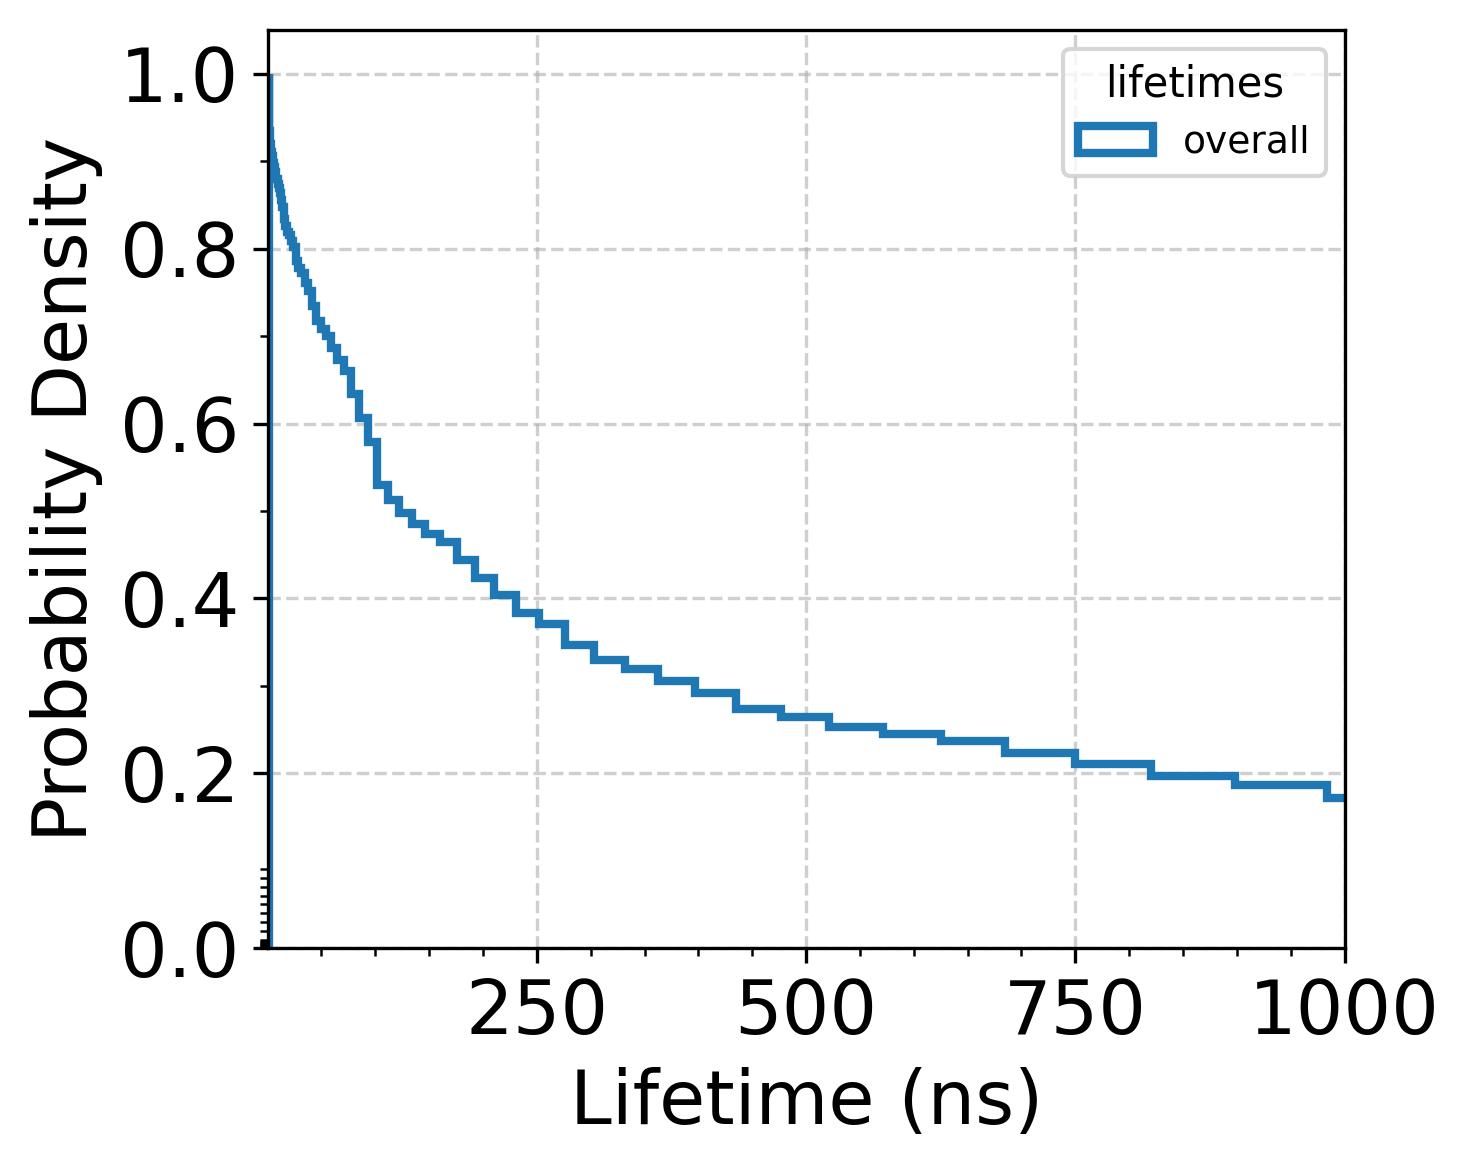

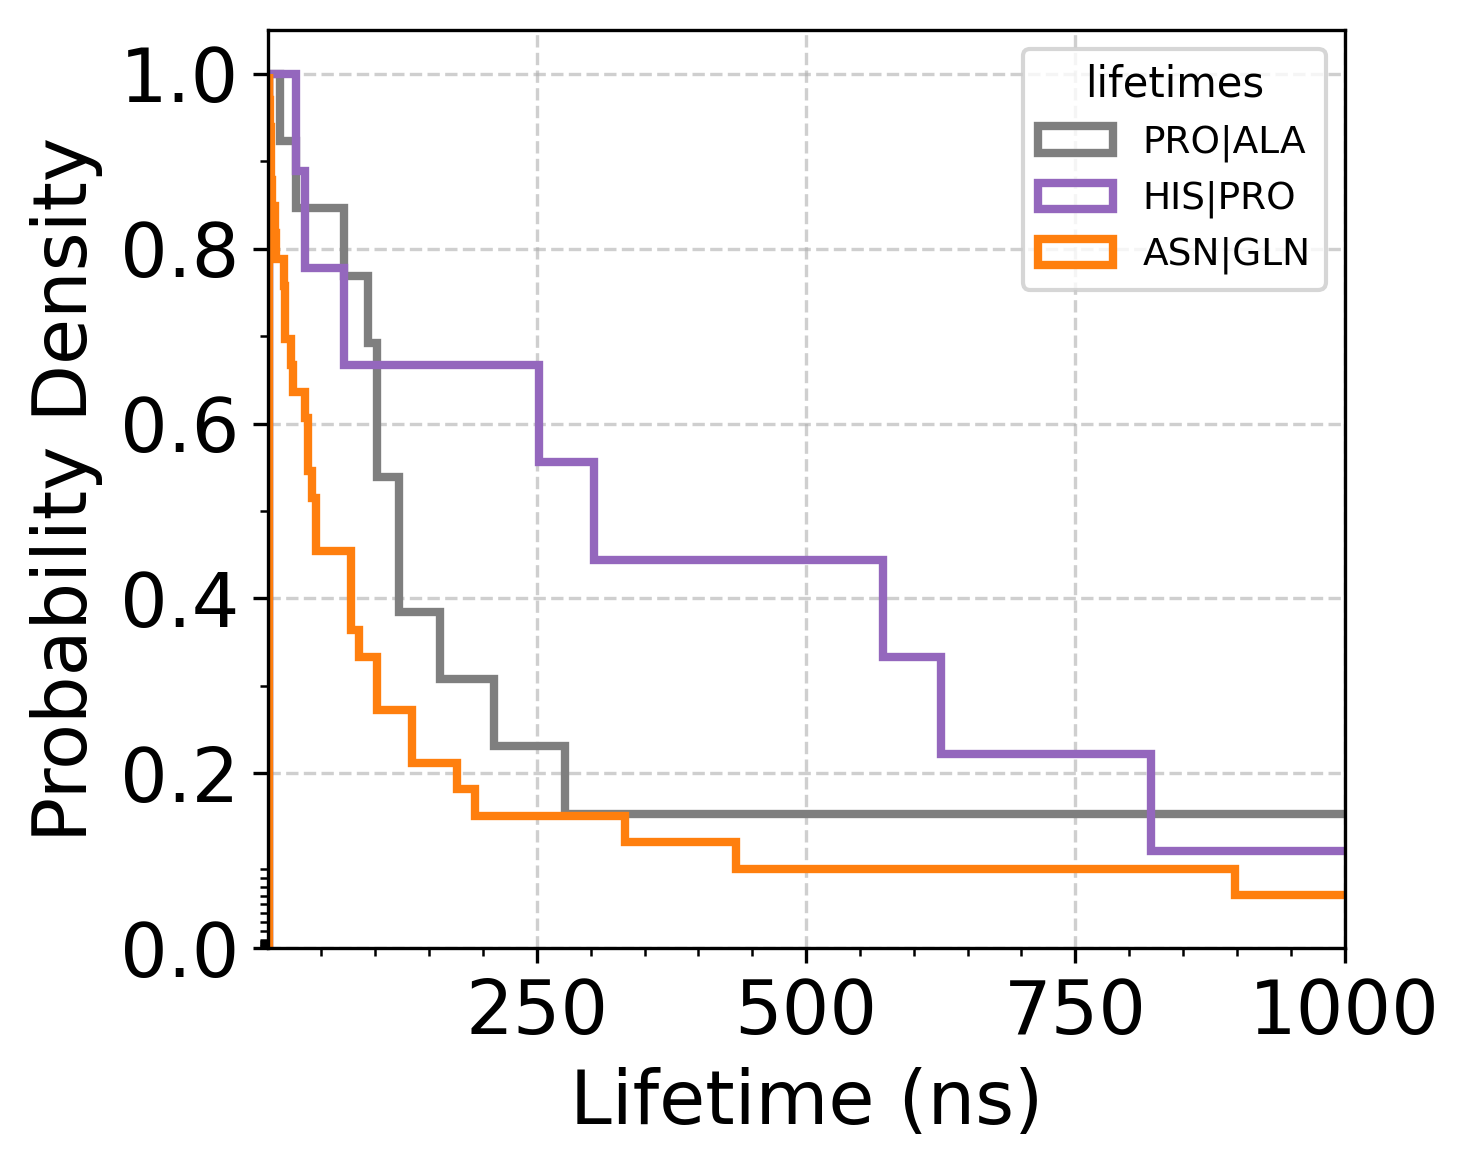

In [21]:
#plot
val_title='lifetimes'
pairs=[["ASN","GLN"],["HIS","PRO"],["PRO","ALA"]]
mat_filtered = contacts_pivot_full_list_perc.map(
lambda lst: [x for x in lst if x >= 0] if isinstance(list(lst), list) else []
)
#data pairs for labeling with color map
all_pairs = list(itertools.product(mat_filtered.index, mat_filtered.columns))
joined_all_pairs = ["_".join(map(str, l)) for l in all_pairs]
unique_pairs = list(dict.fromkeys(joined_all_pairs))
cmap = cm.get_cmap("tab20", len(unique_pairs))
color_map = {p: cmap(i) for i, p in enumerate(unique_pairs)}


ptools.plot_hist(mat_filtered, title, color_map,title=val_title)
ptools.plot_hist(mat_filtered, title, color_map,title=val_title,pairs=pairs)

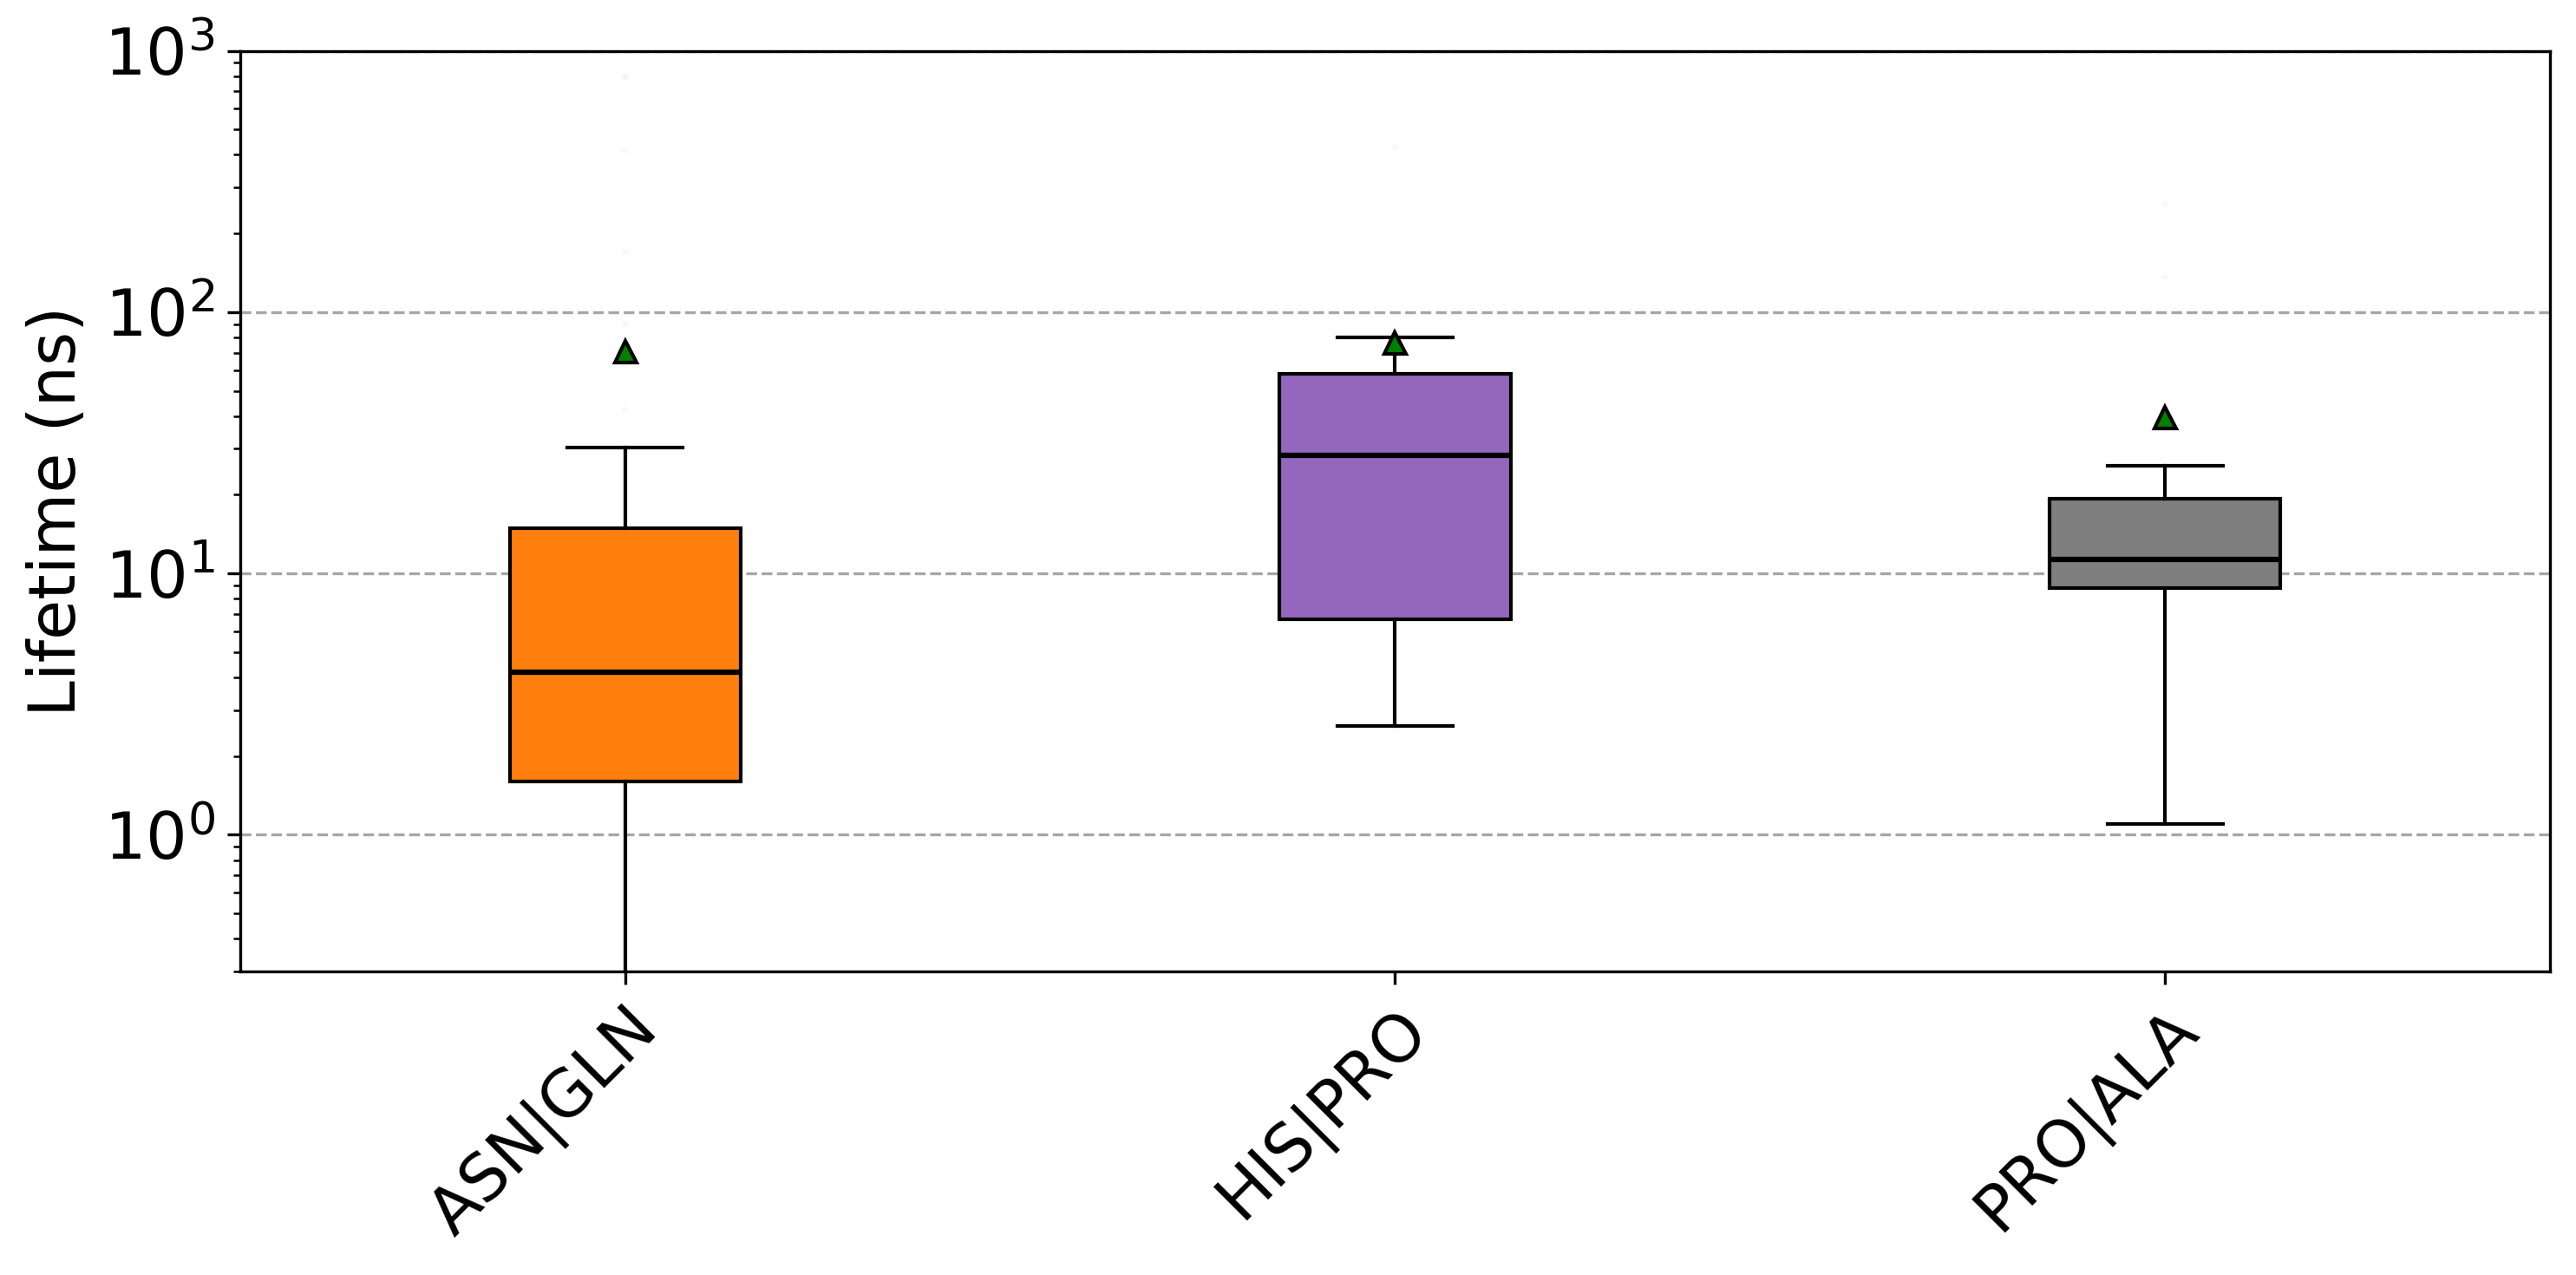

In [22]:
output_filename = '' 
val_title=''
query=["MUT16","MUT16"]
pairs=[["ASN","GLN"],["HIS","PRO"],["PRO","ALA"]]
subquery=np.array(pairs)

mat=ntools.query_slice(query, subquery, job.data['res_type_perc'])

#filter
mat_filtered = mat.map(
lambda lst: [x for x in lst if x >= 1] if isinstance(list(lst), list) else []
)

ptools.plot_boxplots_whisker_scaled(mat_filtered, output_filename, color_map,val_title, scale=0.1, pairs=pairs)

In [23]:
#frequency
contacts_pivot_time = dt_cont_map_all_sym.pivot_table(
index=attr+"_a",
columns=attr+"_b",
values='len_contacts',
aggfunc='sum',
observed=False
)
contacts_pivot_full_time = contacts_pivot_time.reindex(index=attr_val, columns=attr_val,fill_value=0)

contacts_pivot_full_freq = ntools.calc_frequency(contacts_pivot_full_time.astype(float)) 

#save
title=job.doc.params.run+'_'+attr+'_freq_count_pivot.parquet'
contacts_pivot_full_freq.to_parquet(f"{os.path.dirname(job.document['contact_record'])}/{title}",engine="pyarrow")
job.document['res_type_freq']=f"{os.path.dirname(job.document['contact_record'])}/{title}"
job.data['res_type_freq']=contacts_pivot_full_freq

./plot


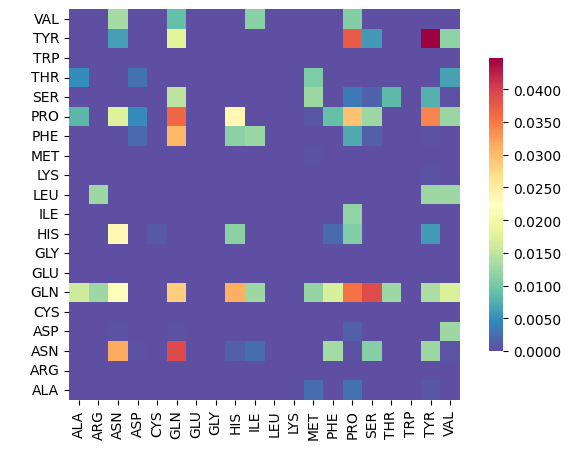

In [24]:
ptools.plot_df(job.data['res_type_freq'])

### normalization by residue abundance

In [25]:
#check abundance of amino acids
res_types_df=ntools.eval_aa_table(contact_meta, name='MUT16_chain')
res_types_df.head()

/Users/lucia/cc/cascade_computing/examples/../../cascade_computing/src/compute/utils/toolbox_normalization.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.groupby(['struc_id','res_type'])
/Users/lucia/cc/cascade_computing/examples/../../cascade_computing/src/compute/utils/toolbox_normalization.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.groupby(['prot','res_type'])


prot,MUT16,total,MUT16_chain
res_type,,,
ALA,260.0,260.0,4.0
ARG,390.0,390.0,6.0
ASN,1430.0,1430.0,22.0
ASP,520.0,520.0,8.0
CYS,65.0,65.0,1.0


In [26]:
matrix = np.outer(res_types_df['MUT16_chain'], res_types_df['MUT16_chain'])
MUT16_MUT16_int_res_types = pd.DataFrame(matrix, index=res_types_df.index, columns=res_types_df.index)

In [27]:
#normalize frequency
norm_freq_prot_res_type=ntools.normalize_frequency(contacts_pivot_full_time,MUT16_MUT16_int_res_types)

./plot


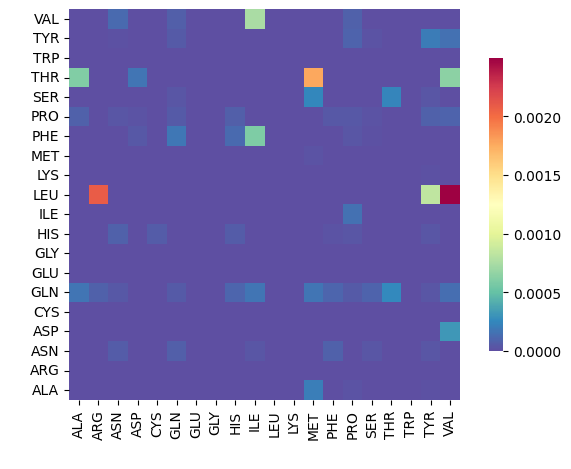

In [28]:
ptools.plot_df(norm_freq_prot_res_type)